In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
import pandas as pd 

from src.models.
from src.utils.datasets import CustomImageDataset
from torch.utils.data import DataLoader

In [2]:
dataset = CustomImageDataset(csv='/home/lucas.ocunha/ConditionalAutoencoder/CSV/PUC/batches/batch-1024.csv', autoencoder=False)
data = DataLoader(dataset)

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

encoder0 = Encoder0()
encoder1 = Encoder1()

encoder0.load_state_dict(torch.load('/home/lucas.ocunha/ConditionalAutoencoder/models/Autoencoder0/PKLot/encoder.pth'))
encoder1.load_state_dict(torch.load('/home/lucas.ocunha/ConditionalAutoencoder/models/Autoencoder1/PKLot/encoder.pth')) 

encoder1.to(device)
encoder0.to(device)

encoder1.eval()
encoder0.eval()

representations0 = []
representations1 = []

y_true = []

In [4]:
for img, label, idx in data:

    img = img.to(device)

    with torch.no_grad():
        rep0 = encoder0(img)
        rep1 = encoder1(img)

    representations0.append(rep0.cpu())
    representations1.append(rep1.cpu())
    y_true.extend(label.cpu().numpy())

In [7]:
%matplotlib inline

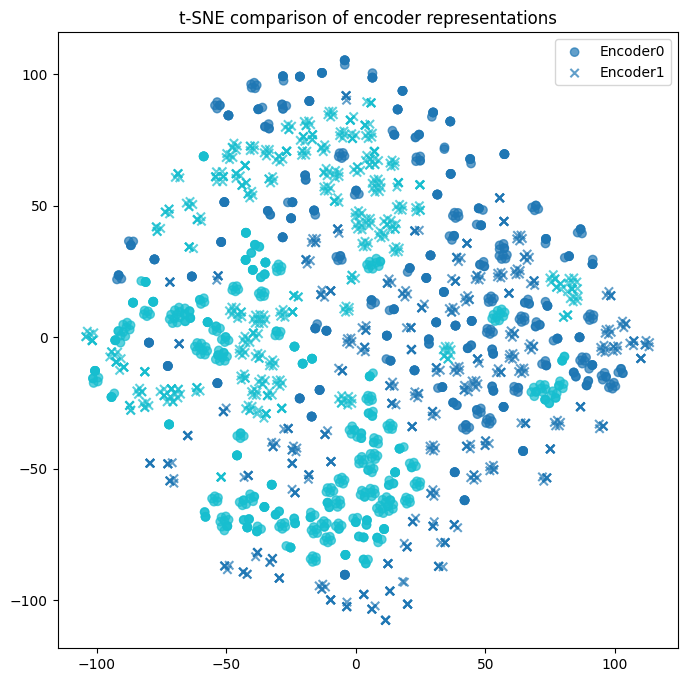

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

rep0 = torch.cat(representations0).numpy()
rep1 = torch.cat(representations1).numpy()

# reduzir ambos para mesma dimensão
pca_dim = min(rep0.shape[1], rep1.shape[1])

pca0 = PCA(n_components=pca_dim)
pca1 = PCA(n_components=pca_dim)

rep0_pca = pca0.fit_transform(rep0)
rep1_pca = pca1.fit_transform(rep1)

# juntar
rep_all = np.concatenate([rep0_pca, rep1_pca], axis=0)

tsne = TSNE(n_components=2, random_state=42)
rep_all_2d = tsne.fit_transform(rep_all)

n = rep0.shape[0]
rep0_2d = rep_all_2d[:n]
rep1_2d = rep_all_2d[n:]

plt.figure(figsize=(8,8))

plt.scatter(rep0_2d[:,0], rep0_2d[:,1],
            c=y_true, cmap="tab10",
            marker="o", label="Encoder0", alpha=0.7)

plt.scatter(rep1_2d[:,0], rep1_2d[:,1],
            c=y_true, cmap="tab10",
            marker="x", label="Encoder1", alpha=0.7)

plt.legend()
plt.title("t-SNE comparison of encoder representations")
plt.show()

In [19]:
from sklearn.metrics.pairwise import euclidean_distances

dist_matrix = euclidean_distances(rep0_2d, rep1_2d)

mean_distance = dist_matrix.mean()

print("Distância média entre embeddings:", mean_distance)

Distância média entre embeddings: 88.54432
